# Support Vector Machines: exercises



## Exercises in this notebook

1. **Artificial datasets**

- Use `make_classifiers`, `make_circles`, `make_blobs` to generate artificial datasets of size 500 with 2 classes and 2 input features. Run SVC, measure error with cross validation and plot boundaries. The aim of this exercise is to obtain different datasets where:
    - The linear kernel is the best choice (smaller error)
    - The polynomial kernel is the best choice  (smaller error)
    - The radial basis kernel is the best choice  (smaller error)
        - Then produce datasets that prefer different values of gamma

2. **The linear kernel in C-SVC**

- Use the breast cancer dataset from `sklearn.datasets`. With the linear kernel, study how the number of support vectors changes with `C`. Plot the result.
- Now obtain the error (using cross validation) for the linear kernel for the value of `C`with the least support vectors you found.
- Plot the cross validated estimated generalization error against different values of `C`. Try to obtain a point with a minimum error value. What do you observe?
- Plot two lines against `C`: one with **cv error** and the other with $|SV|/N-1$, where $|SV|$ is the number of support vectors and $N$ is the number of training cases.
- How do you explain the result?
- Perform a similar study with other datasets

3. **Using other kernels**

- Use the Pima Indians dataset and minimize cv error using linear, radial basis and polynomial kernels with different values of `C`. Which combination gave the best value? Spoiler: the best kernel is not the linear (in my experiments), but there is only a tiny difference.
- Use the digits dataset from `sklearn.datasets`. Find the best kernel and C. Spoiler: the best error does not correspond to the smallest value of `C`. Is is not obtained with the linear kernel, either (in my experiments).

## Imports Needed

In [31]:
from sklearn.svm import SVC # "Support vector classifier"
from sklearn.datasets import make_classification
from sklearn.datasets import make_circles
from sklearn.datasets import make_blobs
from sklearn.model_selection import cross_val_score


import matplotlib.pyplot as plt

import numpy as np


In [12]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=120, edgecolors='red', facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

## 1. **Artificial datasets**

- Use `make_classifiers`, `make_circles`, `make_blobs` to generate artificial datasets of size 500 with 2 classes and 2 input features. Run SVC, measure error with cross validation and plot boundaries. The aim of this exercise is to obtain different datasets where:
    - The linear kernel is the best choice (smaller error)
    - The polynomial kernel is the best choice  (smaller error)
    - The radial basis kernel is the best choice  (smaller error)
        - Then produce datasets that prefer different values of gamma

> O **error** que consideramos acima, consiste na percentagem de pontos que foram mal classificados (os pontos que estão dentro da margem, mas estão corretamente classificados não afetam o erro de classificação, mas afetam o **Hinge Loss** )

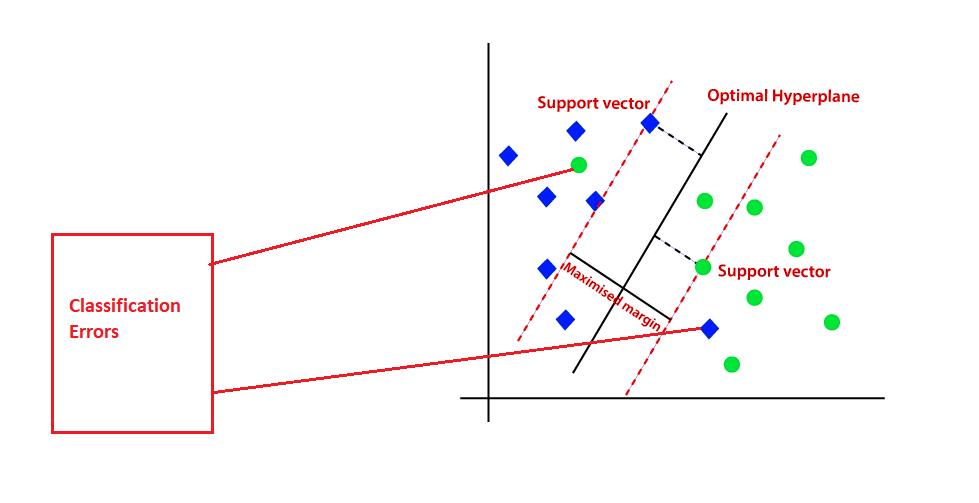

### make_classifiers

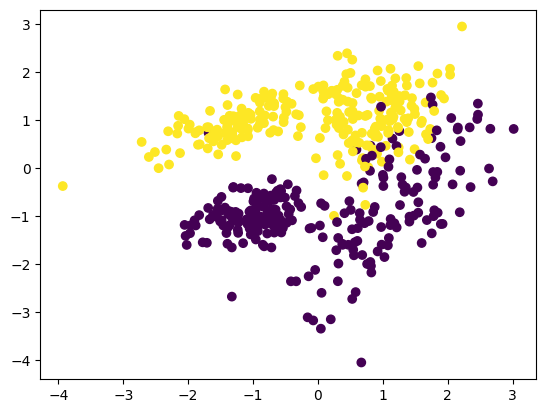

In [11]:
# Generate artificial datasets of size 500 with 2 classes and 2 input features
X,y = make_classification(n_samples=500,n_features=2,
                          n_clusters_per_class=2,
                          n_redundant=0,class_sep=1,
                          random_state=4)

plt.scatter(X[:,0],X[:,1],c=y)

#### Comparison of error between linear, polynomial and radial basis kernels

Linear kernel results: 
   #Support Vectors 91
   Error =  0.07400000000000007


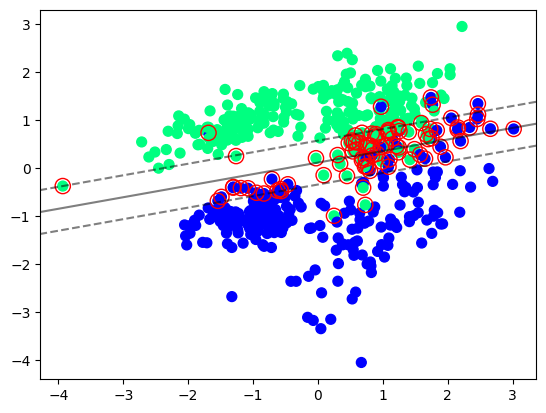

In [19]:
# Linear Kernel
model = SVC(kernel='linear',  C=1)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model, plot_support=True)
print("Linear kernel results: ")
print("   #Support Vectors",len(model.support_vectors_))
print("   Error = ", 1-np.mean(cross_val_score(model,X,y)))

Polynomial kernel results: 
   #Support Vectors 110
   Error =  0.07800000000000007


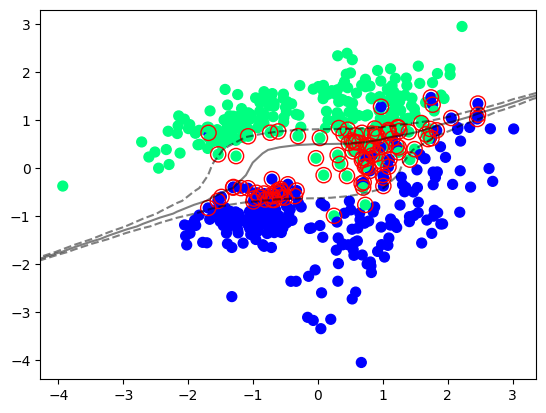

In [21]:

# Polynomial Kernel
model = SVC(kernel='poly',  C=100)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model, plot_support=True)
print("Polynomial kernel results: ")
print("   #Support Vectors",len(model.support_vectors_))
print("   Error = ", 1-np.mean(cross_val_score(model,X,y)))

Radial basis kernel  results: 
  #Support Vectors = 134
  Error = 0.062000000000000055


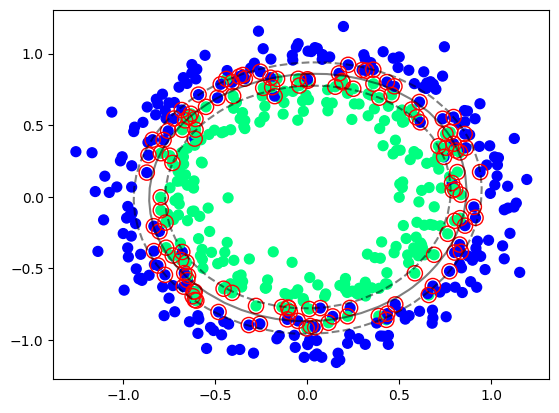

In [30]:
# radial basis kernel 
model = SVC(kernel='rbf',C=10,gamma=0.34).fit(X, y)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model, plot_support=True)
print("Radial basis kernel  results: ")

print("  #Support Vectors =",len(model.support_vectors_))
print("  Error =",1-np.mean(cross_val_score(model,X,y)))

* Erro de cada kernel:
    * Erro Linear = 0.074
    * Erro Polynomial = 0.078
    * Erro Radial = 0.044
* **Conclusão:**
    * O kernel radial teve menor erro para o dataset gerado com make_classification



### make_circles

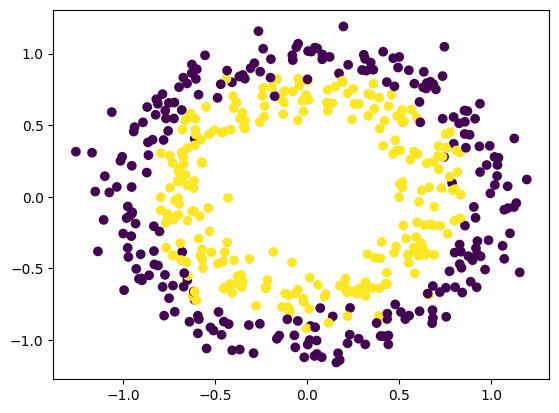

In [24]:
X, y = make_circles(500, factor=0.7, noise=.1, random_state=0)
plt.scatter(X[:,0],X[:,1],c=y)

#### Comparison of error between linear, polynomial and radial basis kernels

Linear kernel results: 
   #Support Vectors 498
   Error =  0.5439999999999999


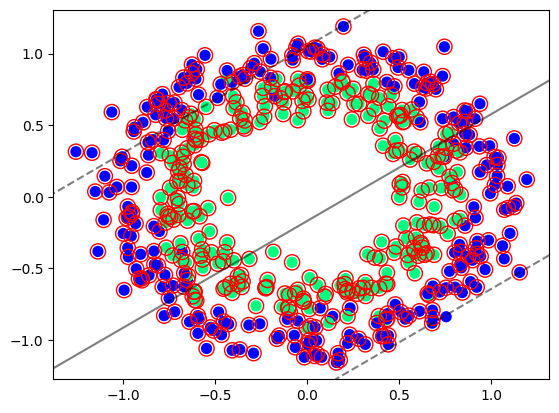

In [27]:
# Linear Kernel
model = SVC(kernel='linear',  C=1)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model, plot_support=True)
print("Linear kernel results: ")
print("   #Support Vectors",len(model.support_vectors_))
print("   Error = ", 1-np.mean(cross_val_score(model,X,y)))

Polynomial kernel results: 
   #Support Vectors 495
   Error =  0.396


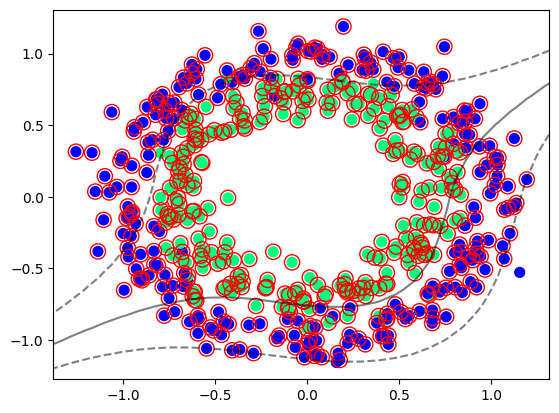

In [28]:
# Polynomial Kernel
model = SVC(kernel='poly',  C=100)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model, plot_support=True)
print("Polynomial kernel results: ")
print("   #Support Vectors",len(model.support_vectors_))
print("   Error = ", 1-np.mean(cross_val_score(model,X,y)))

Radial basis kernel  results: 
  #Support Vectors = 134
  Error = 0.062000000000000055


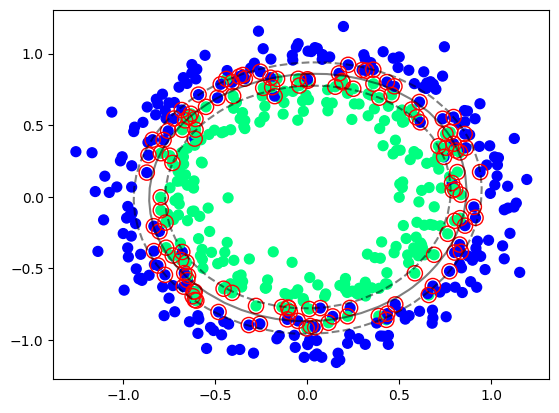

In [29]:

# radial basis kernel 
model = SVC(kernel='rbf',C=10,gamma=0.34).fit(X, y)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model, plot_support=True)
print("Radial basis kernel  results: ")
print("  #Support Vectors =",len(model.support_vectors_))
print("  Error =",1-np.mean(cross_val_score(model,X,y)))


* Erro de cada kernel:
    * Erro Linear = 0.544
    * Erro Polynomial = 0.396
    * Erro Radial = 0.062
* **Conclusão:**
    * O kernel radial teve menor erro para o dataset gerado com make_circles


### make_blobs

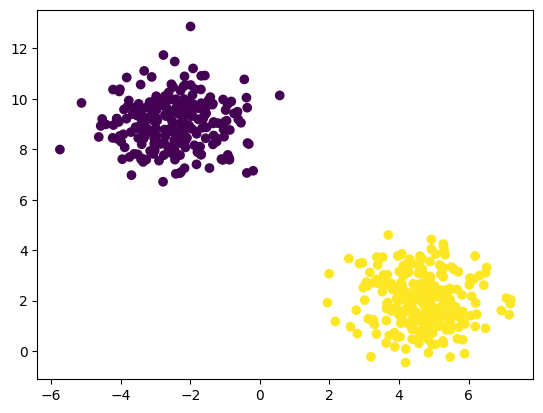

In [33]:
X, y = make_blobs(n_samples=500, centers=2, n_features=2, random_state=42)
plt.scatter(X[:,0],X[:,1],c=y);

#### Comparison of error between linear, polynomial and radial basis kernels

Linear kernel results: 
   #Support Vectors 3
   Error =  0.0


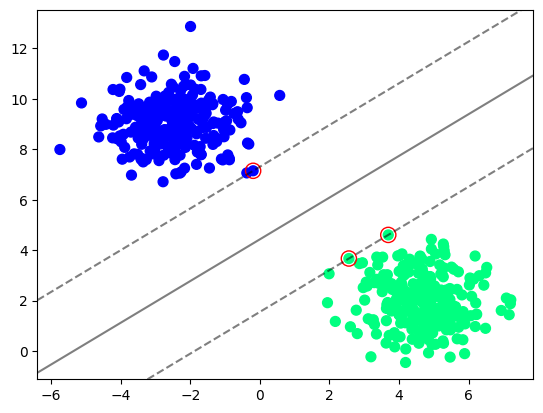

In [34]:
# Linear Kernel
model = SVC(kernel='linear',  C=1)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model, plot_support=True)
print("Linear kernel results: ")
print("   #Support Vectors",len(model.support_vectors_))
print("   Error = ", 1-np.mean(cross_val_score(model,X,y)))

Polynomial kernel results: 
   #Support Vectors 3
   Error =  0.0


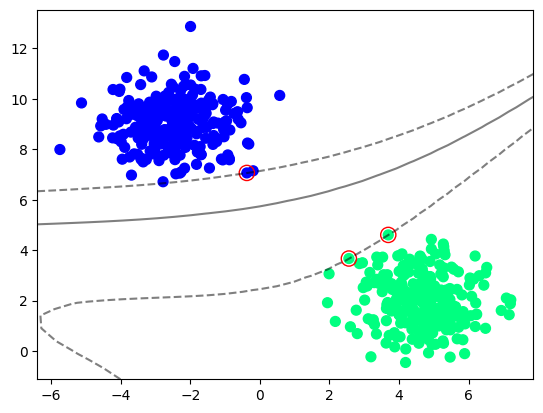

In [35]:
# Polynomial Kernel
model = SVC(kernel='poly',  C=100)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model, plot_support=True)
print("Polynomial kernel results: ")
print("   #Support Vectors",len(model.support_vectors_))
print("   Error = ", 1-np.mean(cross_val_score(model,X,y)))

Radial basis kernel  results: 
  #Support Vectors = 32
  Error = 0.0


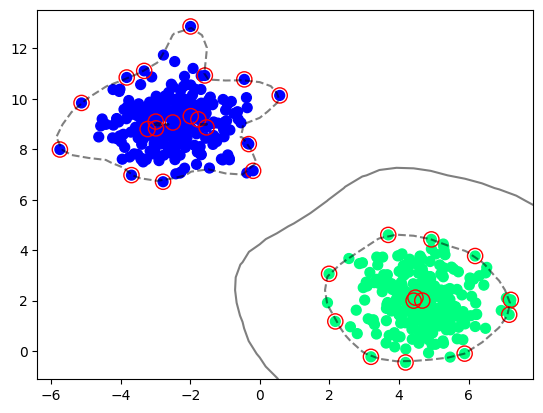

In [36]:

# radial basis kernel 
model = SVC(kernel='rbf',C=10,gamma=0.34).fit(X, y)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model, plot_support=True)
print("Radial basis kernel  results: ")
print("  #Support Vectors =",len(model.support_vectors_))
print("  Error =",1-np.mean(cross_val_score(model,X,y)))

* Erro de cada kernel:
    * Erro Linear = 0.0
    * Erro Polynomial = 0.0
    * Erro Radial = 0.0
* **Conclusão:**
    * Todos os kernels tem erro = 0, o que significa que não tem nenhuma classificação errada,

## 2. The linear kernel in C-SVC



- Use the breast cancer dataset from `sklearn.datasets`. With the linear kernel, study how the number of support vectors changes with `C`. Plot the result.
- Now obtain the error (using cross validation) for the linear kernel for the value of `C`with the least support vectors you found.
- Plot the cross validated estimated generalization error against different values of `C`. Try to obtain a point with a minimum error value. What do you observe?
- Plot two lines against `C`: one with **cv error** and the other with $|SV|/N-1$, where $|SV|$ is the number of support vectors and $N$ is the number of training cases.
- How do you explain the result?
- Perform a similar study with other datasets

In [38]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score


data = load_breast_cancer()
X = data.data
y = data.target

model = SVC(kernel='linear',  C=1)
model.fit(X, y)
print("# Support Vector = ", len(model.support_vectors_))
print(np.shape(X))
print("Error = ",1-np.mean(cross_val_score(model,X,y)))
print(model.gamma)

# Support Vector =  57
(569, 30)
Error =  0.054463592609843126
scale


Text(0.5, 0, '# of Support Vectors')

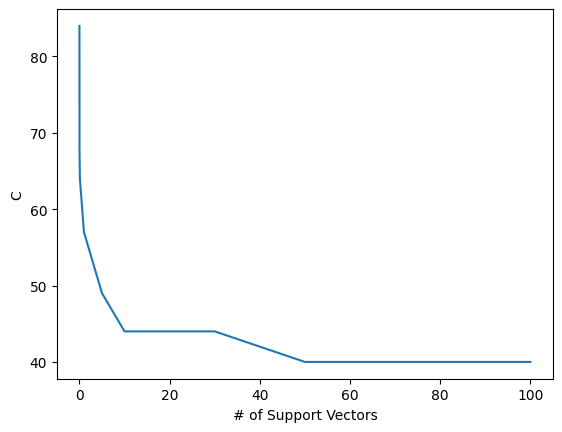

In [42]:
Cvec=[0.001,0.01,0.1,1,5,10,15,20,30, 40, 50, 60,70,80,90,100]
C_error_SV = [] # List to hold triples of C/error value/Number of support vectors of the model

def sv(C, kernel='linear'):
    model = SVC(kernel=kernel,  C=C)
    model.fit(X, y)
    error = 1-np.mean(cross_val_score(model,X,y))
    nr_sv = len(model.support_vectors_)
    C_error_SV.append((C,error,nr_sv))
    return(len(model.support_vectors_))

svvec=list(map(sv,Cvec))
plt.plot(Cvec,svvec);
plt.ylabel("C")
plt.xlabel("# of Support Vectors")


R: Da figura acima concluimos que à medida que o valor de C aumenta, o número de Support vectors diminui.

```Nota:``` **O parâmetro C** é o **fator de Regularização (ou penalidade por erro)**. Ele **controla o equilíbrio** entre ter uma **"margem larga" e "classificar corretamente todos os pontos de treino"**.

* ```Quando C é Baixo```:
    * **Significado:** O modelo é "Tolerante". A penalidade por errar é pequena.

    * **Comportamento:** O SVM prefere criar uma **margem muito larga** , mesmo que isso signifique que muitos pontos fiquem dentro da margem ou sejam classificados incorretamente.

    * **Consequência na figura:** Como a margem é larga, ela "engloba" ou toca em muitos pontos. Todos esses pontos tornam-se Support Vectors. Por isso, o **número de Support Vectors é alto**.
* ```Quando C é Alto```:
    * **Significado:** O modelo é "Rigoroso". A penalidade por errar é alta.
    * **Comportamento:** O SVM tenta não cometer erros. Para conseguir separar classes difíceis sem errar, ele é forçado a **estreitar a margem**  para passar exatamente entre os pontos sem tocar neles.
    * **Consequência na figura:** Uma margem estreita toca em menos pontos. Apenas os pontos estritamente necessários para definir essa fronteira fina são usados. Por isso, **temos menos Support Vectors**.


In [43]:
for i in C_error_SV: 
    print(i)

(0.001, np.float64(0.05974227604409266), 84)
(0.01, np.float64(0.05270920664493095), 68)
(0.1, np.float64(0.050954820680018664), 64)
(1, np.float64(0.054463592609843126), 57)
(5, np.float64(0.049184909175593816), 49)
(10, np.float64(0.04743052321068153), 44)
(15, np.float64(0.04392175128085718), 44)
(20, np.float64(0.0509392951405061), 44)
(30, np.float64(0.04566061170625679), 44)
(40, np.float64(0.04390622574134451), 42)
(50, np.float64(0.04390622574134451), 40)
(60, np.float64(0.03688868188169536), 40)
(70, np.float64(0.03336438441235823), 40)
(80, np.float64(0.035118770377270514), 40)
(90, np.float64(0.03687315634218291), 40)
(100, np.float64(0.03687315634218291), 40)


* P: Now obtain the error (using cross validation) for the linear kernel for the value of `C`with the least support vectors you found.
    * R: Modelo com menor número de Support Vectors:
        * C = 10
        * Erro =  0.04743052321068153
        * \#Support vectors = 44

Text(0.5, 0, 'C')

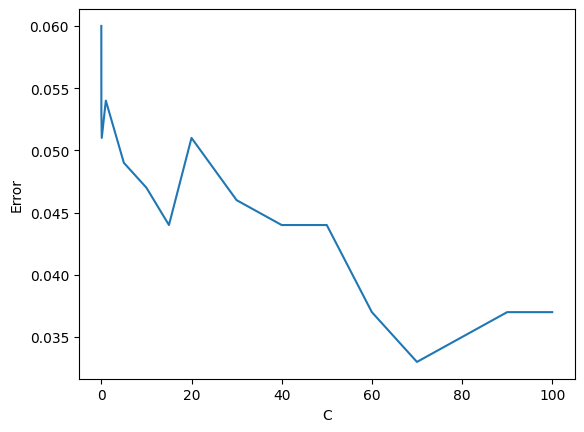

In [ ]:

x = [] 
y = []
for i in C_error_SV:
    x.append(i[0])
    y.append(np.round(i[1],3))

plt.plot(x,y)
plt.ylabel("Error")
plt.xlabel("C")



* Plot the cross validated estimated generalization error against different values of `C`. Try to obtain a point with a minimum error value. 
    * What do you observe?
        * R: O Trade-off de Regularização: O gráfico ilustra visualmente o conceito de trade-off controlado pelo parâmetro C:
            * **C baixo:** O modelo é mais "suave" (soft-margin), **permite mais erros para ter uma margem de separação mais ampla**, o que pode levar a um **underfitting** (erros mais altos no início do gráfico).
            * **C alto:** O modelo é mais "rígido" (hard-margin), **busca minimizar os erros a todo custo** (erros menores em torno de C=70), mas valores muito altos podem causar **overfitting** (erros ligeiramente maiores/estabilizados no final do gráfico). 
    

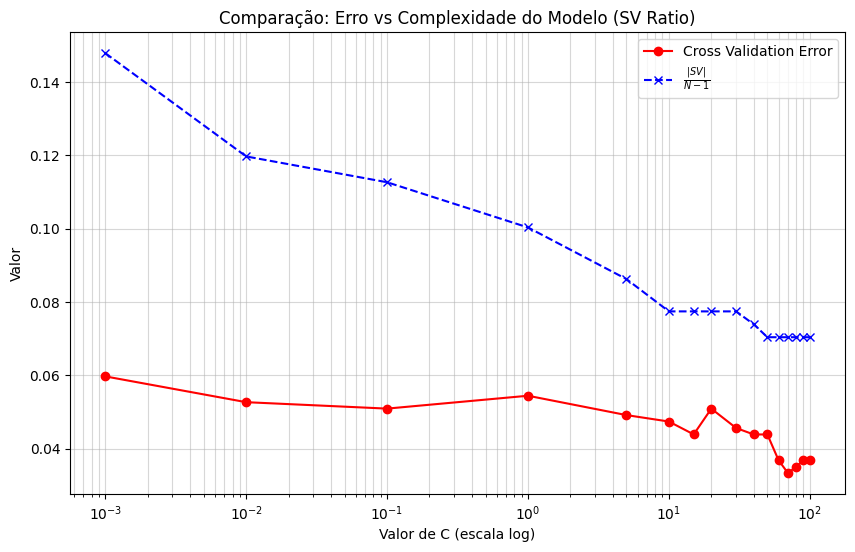

In [ ]:
#Plot two lines against `C`: one with **cv error** and the other with $|SV|/N-1$, where $|SV|$ is the number of support vectors and $N$ is the number of training cases.


c_values = [r[0] for r in C_error_SV]
errors   = [r[1] for r in C_error_SV]
sv_counts= [r[2] for r in C_error_SV]

#  |SV| / (N - 1)
sv_metric = [sv / (len(X) - 1) for sv in sv_counts]


plt.figure(figsize=(10, 6))

# Plot 1: Cross Validation Error
plt.plot(c_values, errors, label='Cross Validation Error', color='red', marker='o', linestyle='-')

# Plot 2: |SV| / (N - 1)
plt.plot(c_values, sv_metric, label=r'$\frac{|SV|}{N-1}$', color='blue', marker='x', linestyle='--')

plt.xscale('log') # Escala logarítmica é essencial para visualizar C
plt.xlabel('Valor de C (escala log)')
plt.ylabel('Valor')
plt.title('Comparação: Erro vs Complexidade do Modelo (SV Ratio)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()

* P:  How do you explain the result?
    * R: 
        * **A Linha Azul: O Comportamento dos Vetores de Suporte**
            * **C Baixo (Esquerda):** O modelo é "tolerante". A **margem é larga** e engloba muitos pontos.
            * **C Alto (Direita):** O modelo é "rígido". A **margem estreita-se** para evitar erros. O modelo descarta a maioria dos pontos e foca apenas nos ~7% mais difíceis (os que estão na fronteira da decisão).
        * **A Linha Vermelha: A Performance Real (Erro)**
            * **Observação:** A linha vermelha (Cross Validation Error) começa em torno de 0.06, mantém-se estável e depois cai bruscamente para cerca de 0.035 quando $C > 50$.
            * **Conclusão:** Para este conjunto de dados específico (Breast Cancer), **modelos com C alto funcionam melhor**. O modelo precisa de ser rigoroso e ter uma margem fina para separar corretamente os casos de cancro benigno e maligno sem cometer erros.

## 3. Using other kernels

- Use the Pima Indians dataset and minimize cv error using linear, radial basis and polynomial kernels with different values of `C`. Which combination gave the best value? Spoiler: the best kernel is not the linear (in my experiments), but there is only a tiny difference.
- Use the digits dataset from `sklearn.datasets`. Find the best kernel and C. Spoiler: the best error does not correspond to the smallest value of `C`. Is is not obtained with the linear kernel, either (in my experiments).

> Não fiz este exercicio